### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

In [1]:

from __future__ import absolute_import, division, print_function, unicode_literals

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

1.13.1


### Load tensorflow

In [2]:
#import tensorflow as tf
#tf.set_random_seed(42)

In [3]:
#tf.__version__

### Collect Data

In [4]:
import keras

Using TensorFlow backend.


In [5]:
#(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

In [8]:
mnist1 = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = mnist1.load_data()

4423680/4422102 [==============================] - 3s 1us/step


In [9]:
print(test_labels[0:10])

[9 2 1 1 6 1 4 6 5 7]


### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [10]:
train_images.shape

(60000, 28, 28)

In [11]:
len(train_labels)

60000

In [12]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [13]:
test_images.shape

(10000, 28, 28)

In [14]:
len(test_labels)

10000

In [16]:
print(train_labels.shape)
print('First 10 examples now are: ', train_labels[0:10])

(60000,)
First 10 examples now are:  [9 0 0 3 0 2 7 2 5 5]


### Visualize the data

Plot first 10 images in the triaining set and their labels.

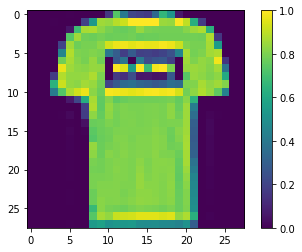

In [48]:
plt.figure()
plt.imshow(train_images[1])
plt.colorbar()
plt.grid(False)
plt.show()

In [18]:

train_images = train_images / 255.0

test_images = test_images / 255.0

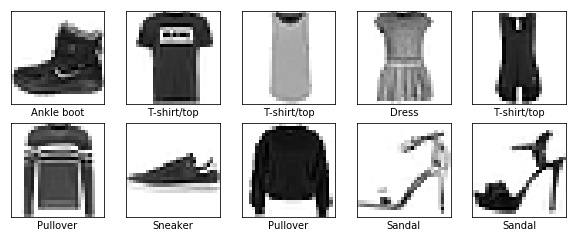

In [19]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [49]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [50]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Execute the model using model.fit()

In [51]:
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
60000/60000 [==============================] - 10s 160us/step - loss: 0.5009 - acc: 0.8244
Epoch 2/10
60000/60000 [==============================] - 9s 143us/step - loss: 0.3759 - acc: 0.8636
Epoch 3/10
60000/60000 [==============================] - 8s 139us/step - loss: 0.3375 - acc: 0.8764
Epoch 4/10
60000/60000 [==============================] - 8s 136us/step - loss: 0.3133 - acc: 0.8859
Epoch 5/10
60000/60000 [==============================] - 8s 132us/step - loss: 0.2952 - acc: 0.8915
Epoch 6/10
60000/60000 [==============================] - 8s 135us/step - loss: 0.2778 - acc: 0.8973
Epoch 7/10
60000/60000 [==============================] - 8s 132us/step - loss: 0.2658 - acc: 0.9014
Epoch 8/10
60000/60000 [==============================] - 8s 134us/step - loss: 0.2551 - acc: 0.9052
Epoch 9/10
60000/60000 [==============================] - 8s 132us/step - loss: 0.2473 - acc: 0.9087
Epoch 10/10
60000/60000 [==============================] - 8s 132us/step - loss: 0.2369 - 

### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [54]:
model.fit(train_images, train_labels, epochs=10, batch_size=60)

Epoch 1/10
60000/60000 [==============================] - 5s 82us/step - loss: 0.2090 - acc: 0.9214
Epoch 2/10
60000/60000 [==============================] - 5s 79us/step - loss: 0.2048 - acc: 0.9236
Epoch 3/10
60000/60000 [==============================] - 5s 82us/step - loss: 0.2018 - acc: 0.9247
Epoch 4/10
60000/60000 [==============================] - 5s 82us/step - loss: 0.1970 - acc: 0.9267
Epoch 5/10
60000/60000 [==============================] - 6s 97us/step - loss: 0.1899 - acc: 0.9293
Epoch 6/10
60000/60000 [==============================] - 5s 80us/step - loss: 0.1881 - acc: 0.9290
Epoch 7/10
60000/60000 [==============================] - 5s 77us/step - loss: 0.1817 - acc: 0.9326
Epoch 8/10
60000/60000 [==============================] - 5s 81us/step - loss: 0.1780 - acc: 0.9338
Epoch 9/10
60000/60000 [==============================] - 5s 79us/step - loss: 0.1717 - acc: 0.9361
Epoch 10/10
60000/60000 [==============================] - 5s 79us/step - loss: 0.1665 - acc: 0.9376

### Execute the model

In [56]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print('Test accuracy:', test_acc)

10000/10000 [==============================] - 1s 52us/step
Test accuracy: 0.8941


In [57]:
predictions = model.predict(test_images)

In [58]:
predictions[0]
np.argmax(predictions[0])

test_labels[0]

9

In [59]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  
  plt.imshow(img, cmap=plt.cm.binary)
  
  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'
  
  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array[i], true_label[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)
  
  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

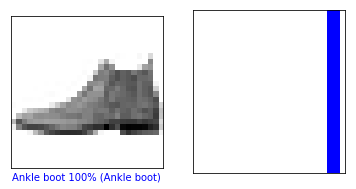

In [60]:

i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions, test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions,  test_labels)
plt.show()

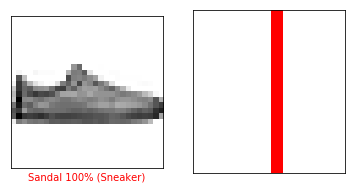

In [61]:
i = 12
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions, test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions,  test_labels)
plt.show()


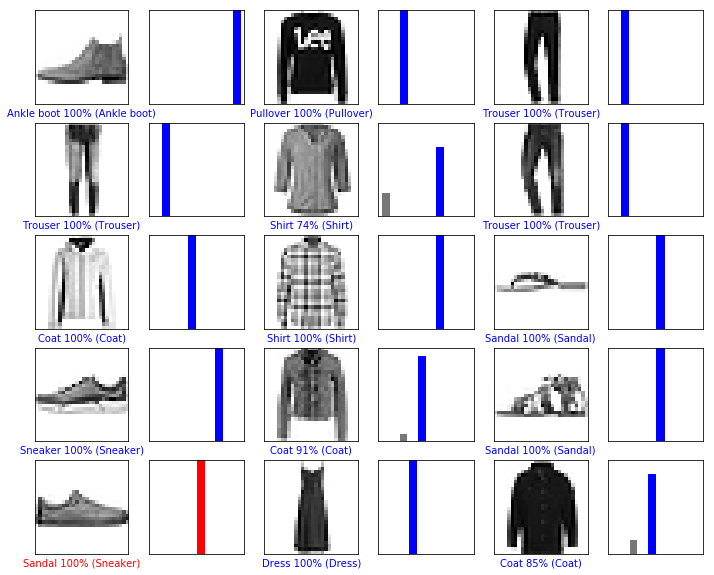

In [62]:

# Plot the first X test images, their predicted label, and the true label
# Color correct predictions in blue, incorrect predictions in red
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions, test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions, test_labels)
plt.show()

In [63]:
# Grab an image from the test dataset
img = test_images[0]

print(img.shape)

(28, 28)


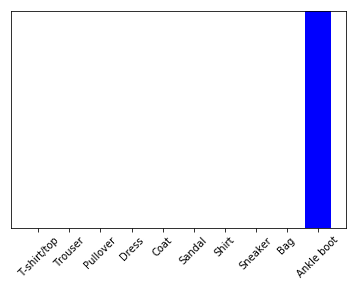

In [67]:
plot_value_array(0, predictions, test_labels)
plt.xticks(range(10), class_names, rotation=45)
plt.show()

In [68]:
prediction_result = np.argmax(predictions[0])
print(prediction_result)

9


### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [69]:
from keras import optimizers
# All parameter gradients will be clipped to
# a maximum norm of 1.
sgd = optimizers.SGD(lr=0.001, clipnorm=1.)
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [71]:
model.fit(train_images, train_labels, epochs=10, batch_size=60)

Epoch 1/10
60000/60000 [==============================] - 4s 64us/step - loss: 0.1277 - acc: 0.9535
Epoch 2/10
60000/60000 [==============================] - 4s 64us/step - loss: 0.1271 - acc: 0.9543
Epoch 3/10
60000/60000 [==============================] - 4s 65us/step - loss: 0.1265 - acc: 0.9539
Epoch 4/10
60000/60000 [==============================] - 4s 63us/step - loss: 0.1262 - acc: 0.9541
Epoch 5/10
60000/60000 [==============================] - 4s 64us/step - loss: 0.1256 - acc: 0.9547
Epoch 6/10
60000/60000 [==============================] - 4s 63us/step - loss: 0.1251 - acc: 0.9550: 0s - loss: 0.125
Epoch 7/10
60000/60000 [==============================] - 4s 63us/step - loss: 0.1248 - acc: 0.9543
Epoch 8/10
60000/60000 [==============================] - 4s 64us/step - loss: 0.1243 - acc: 0.9551
Epoch 9/10
60000/60000 [==============================] - 4s 64us/step - loss: 0.1239 - acc: 0.9555
Epoch 10/10
60000/60000 [==============================] - 4s 64us/step - loss: 0.

### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [73]:
tf.keras.activations.sigmoid

<function tensorflow.python.keras.activations.sigmoid(x)>

In [74]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation=tf.nn.sigmoid),
    keras.layers.Dense(100, activation=tf.nn.sigmoid),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [75]:
from keras import optimizers
# All parameter gradients will be clipped to
# a maximum norm of 1.
sgd = optimizers.SGD(lr=0.003, clipnorm=1.)
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [76]:
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
60000/60000 [==============================] - 7s 114us/step - loss: 2.0396 - acc: 0.4267
Epoch 2/10
60000/60000 [==============================] - 6s 100us/step - loss: 1.3563 - acc: 0.6142
Epoch 3/10
60000/60000 [==============================] - 6s 99us/step - loss: 1.0251 - acc: 0.6794
Epoch 4/10
60000/60000 [==============================] - 6s 102us/step - loss: 0.8635 - acc: 0.7178
Epoch 5/10
60000/60000 [==============================] - 6s 97us/step - loss: 0.7608 - acc: 0.7439
Epoch 6/10
60000/60000 [==============================] - 6s 96us/step - loss: 0.6935 - acc: 0.7562
Epoch 7/10
60000/60000 [==============================] - 6s 97us/step - loss: 0.6490 - acc: 0.7663
Epoch 8/10
60000/60000 [==============================] - 6s 98us/step - loss: 0.6176 - acc: 0.7758
Epoch 9/10
60000/60000 [==============================] - 6s 95us/step - loss: 0.5927 - acc: 0.7856
Epoch 10/10
60000/60000 [==============================] - 6s 95us/step - loss: 0.5722 - acc: 0.7

## Review model

In [77]:
model1 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
from keras import optimizers
# All parameter gradients will be clipped to
# a maximum norm of 1.
#sgd = optimizers.SGD(lr=0.001, clipnorm=1.)
model1.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model1.fit(train_images, train_labels, epochs=15, batch_size=60)

Epoch 1/15
60000/60000 [==============================] - 6s 93us/step - loss: 0.5167 - acc: 0.8203
Epoch 2/15
60000/60000 [==============================] - 5s 79us/step - loss: 0.3837 - acc: 0.8633
Epoch 3/15
60000/60000 [==============================] - 5s 81us/step - loss: 0.3453 - acc: 0.8740
Epoch 4/15
60000/60000 [==============================] - 5s 81us/step - loss: 0.3174 - acc: 0.8845
Epoch 5/15
60000/60000 [==============================] - 5s 83us/step - loss: 0.3033 - acc: 0.8891
Epoch 6/15
60000/60000 [==============================] - 5s 78us/step - loss: 0.2864 - acc: 0.8942
Epoch 7/15
60000/60000 [==============================] - 5s 82us/step - loss: 0.2746 - acc: 0.8979
Epoch 8/15
60000/60000 [==============================] - 5s 82us/step - loss: 0.2644 - acc: 0.9021
Epoch 9/15
60000/60000 [==============================] - 5s 83us/step - loss: 0.2548 - acc: 0.9065
Epoch 10/15
60000/60000 [==============================] - 5s 81us/step - loss: 0.2468 - acc: 0.9085

In [78]:
sgdmodel = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
from keras import optimizers
# All parameter gradients will be clipped to
# a maximum norm of 1.
sgd = optimizers.SGD(lr=0.001, clipnorm=1.)
sgdmodel.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
sgdmodel.fit(train_images, train_labels, epochs=15, batch_size=60)

Epoch 1/15
60000/60000 [==============================] - 5s 79us/step - loss: 0.8963 - acc: 0.7184
Epoch 2/15
60000/60000 [==============================] - 4s 66us/step - loss: 0.5764 - acc: 0.8102
Epoch 3/15
60000/60000 [==============================] - 4s 64us/step - loss: 0.5153 - acc: 0.8253
Epoch 4/15
60000/60000 [==============================] - 4s 66us/step - loss: 0.4844 - acc: 0.8361
Epoch 5/15
60000/60000 [==============================] - 4s 66us/step - loss: 0.4643 - acc: 0.8415
Epoch 6/15
60000/60000 [==============================] - 4s 64us/step - loss: 0.4499 - acc: 0.8449
Epoch 7/15
60000/60000 [==============================] - 4s 64us/step - loss: 0.4378 - acc: 0.8491
Epoch 8/15
60000/60000 [==============================] - 4s 65us/step - loss: 0.4279 - acc: 0.8513:
Epoch 9/15
60000/60000 [==============================] - 4s 63us/step - loss: 0.4199 - acc: 0.8557
Epoch 10/15
60000/60000 [==============================] - 4s 63us/step - loss: 0.4120 - acc: 0.858

In [79]:
model3 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
from keras import optimizers
# All parameter gradients will be clipped to
# a maximum norm of 1.
#sgd = optimizers.SGD(lr=0.001, clipnorm=1.)
model3.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model3.fit(train_images, train_labels, epochs=15, batch_size=64)

Epoch 1/15
60000/60000 [==============================] - 6s 107us/step - loss: 0.5030 - acc: 0.8223
Epoch 2/15
60000/60000 [==============================] - 5s 85us/step - loss: 0.3675 - acc: 0.8673
Epoch 3/15
60000/60000 [==============================] - 5s 89us/step - loss: 0.3316 - acc: 0.8787
Epoch 4/15
60000/60000 [==============================] - 5s 89us/step - loss: 0.3064 - acc: 0.8866
Epoch 5/15
60000/60000 [==============================] - 5s 86us/step - loss: 0.2898 - acc: 0.8924
Epoch 6/15
60000/60000 [==============================] - 5s 88us/step - loss: 0.2734 - acc: 0.8986
Epoch 7/15
60000/60000 [==============================] - 5s 88us/step - loss: 0.2628 - acc: 0.9022
Epoch 8/15
60000/60000 [==============================] - 5s 86us/step - loss: 0.2524 - acc: 0.9058
Epoch 9/15
60000/60000 [==============================] - 5s 87us/step - loss: 0.2389 - acc: 0.9104
Epoch 10/15
60000/60000 [==============================] - 5s 88us/step - loss: 0.2356 - acc: 0.911

### Run the model

In [80]:
test_loss, test_acc = model1.evaluate(test_images, test_labels)

print('Test accuracy:', test_acc)

10000/10000 [==============================] - 1s 65us/step
Test accuracy: 0.8906


In [81]:
test_loss, test_acc = sgdmodel.evaluate(test_images, test_labels)

print('Test accuracy:', test_acc)

10000/10000 [==============================] - 1s 82us/step
Test accuracy: 0.851


In [82]:
test_loss, test_acc = model3.evaluate(test_images, test_labels)

print('Test accuracy:', test_acc)

10000/10000 [==============================] - 1s 72us/step
Test accuracy: 0.8875
